In [1]:
# Librerias
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
import time

# import MUSE_utils.PPXF_astrometry_correction as ppxf_ac
import MUSE_utils.PPXF_class as ppxf_c
# import MUSE_utils.PPXF_extinction_correction as ppxf_ec
import MUSE_utils.PPXF_fitting as ppxf_f
import MUSE_utils.PPXF_helper as ppxf_h
# import MUSE_utils.PPXF_redshift_calculator as ppxf_rc
# import MUSE_utils.PPXF_zapping as ppxf_z

import joblib

d:\Universidad\Magister\MUSE PKS0745\MUSE_utils\PPXF_class.py:15: UserWarning: ⚠️ VorBin is deprecated and superseded by PowerBin https://pypi.org/project/powerbin/ 
  from vorbin.voronoi_2d_binning import voronoi_2d_binning


In [ ]:
a = np.array([0,123,143513,np.inf, -np.inf, 12737132,np.nan, 0], '>f8')
print(a)
print(np.isfinite(a))
print(~np.isnan(a))

In [ ]:
t0 = time.time()
gal_NED_id = "MUSE0745"
name_cube = "PKS0745_cube_wcscorr_ext-cor_small.fits"
with fits.open(name_cube) as hdu:
    header_data= hdu[1].header
vvcs= WCS(header_data)
coord = vvcs.pixel_to_world(header_data["NAXIS1"],header_data["NAXIS2"],0)

z = 0.10246 
c = SkyCoord(ra=116.87909416*u.degree, dec=-19.29329137*u.degree, frame="icrs")

lam_range_temp = [4600, 7000]

s = ppxf_h.read_data_cube(name_cube, lam_range_temp, z)#, [75,330],[100,349])

s.outfolder = "./prueba/"
s.start = [0, 200.]    # (km/s), starting guess for [V,sigma]
print(time.time()-t0)

In [2]:
t0 = time.time()
gal_NED_id = "Abell"
name_cube = "Abell1795_corr.fits"
with fits.open(name_cube) as hdu:
    header_data= hdu[1].header
vvcs= WCS(header_data)
coord = vvcs.pixel_to_world(header_data["NAXIS1"],header_data["NAXIS2"],0)

z =  0.06267
c = SkyCoord(ra=116.87909416*u.degree, dec=-19.29329137*u.degree, frame="icrs")

lam_range_temp = [4600, 7000]

s = ppxf_h.read_data_cube(name_cube, lam_range_temp, z, [75,330],[99,349])#[75,330],[100,349]# 84->75 #130,200 250,300

s.outfolder = "./maps_ABELL/"
s.start = [0, 200.]    # (km/s), starting guess for [V,sigma]
print(time.time()-t0)

51.16068148612976


In [3]:
t0 = time.time()
valid = np.isfinite(s.noise)
median_noise = np.nanmedian(s.noise[valid])
s.noise[~valid] = median_noise

valid = np.isfinite(s.signal)
median_s = np.nanmedian(s.signal[valid])
s.signal[~valid] = median_s
print(time.time()-t0)

0.002011537551879883


Running Voronoi binning...


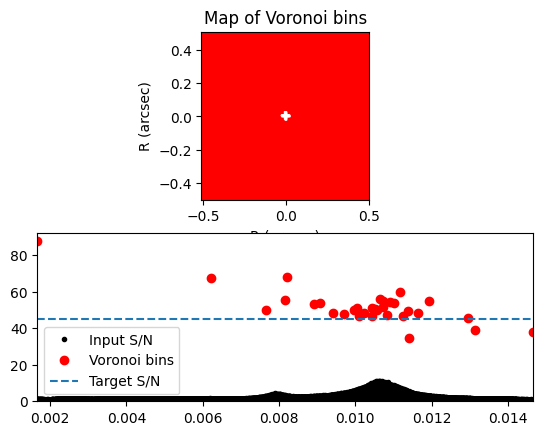

Setting up stellar templates...
1 / 32----------------------------------------------
 Best Fit:       Vel     sigma        h3        h4
 comp.  0:         0       200     0.003     0.003
chi2/DOF: 4.157; DOF: 2077; degree = 10; mdegree = 0
method = capfit; Jac calls: 1; Func calls: 7; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 1/150
 Best Fit:       Vel     sigma        h3        h4
 comp.  0:        40       271     0.070    -0.056
chi2/DOF: 0.08016; DOF: 1693; degree = 10; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 18; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 1/150
 Best Fit:       Vel     sigma
 comp.  0:        40       271
chi2/DOF: 0.09842; DOF: 1689; degree = -1; mdegree = 8
method = capfit; Jac calls: 3; Func calls: 29; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/150
Voronoi bin 1 / 32; SPS: emiles; $\sigma$=271 km/s; S/N=26.6
##############################################################################
We

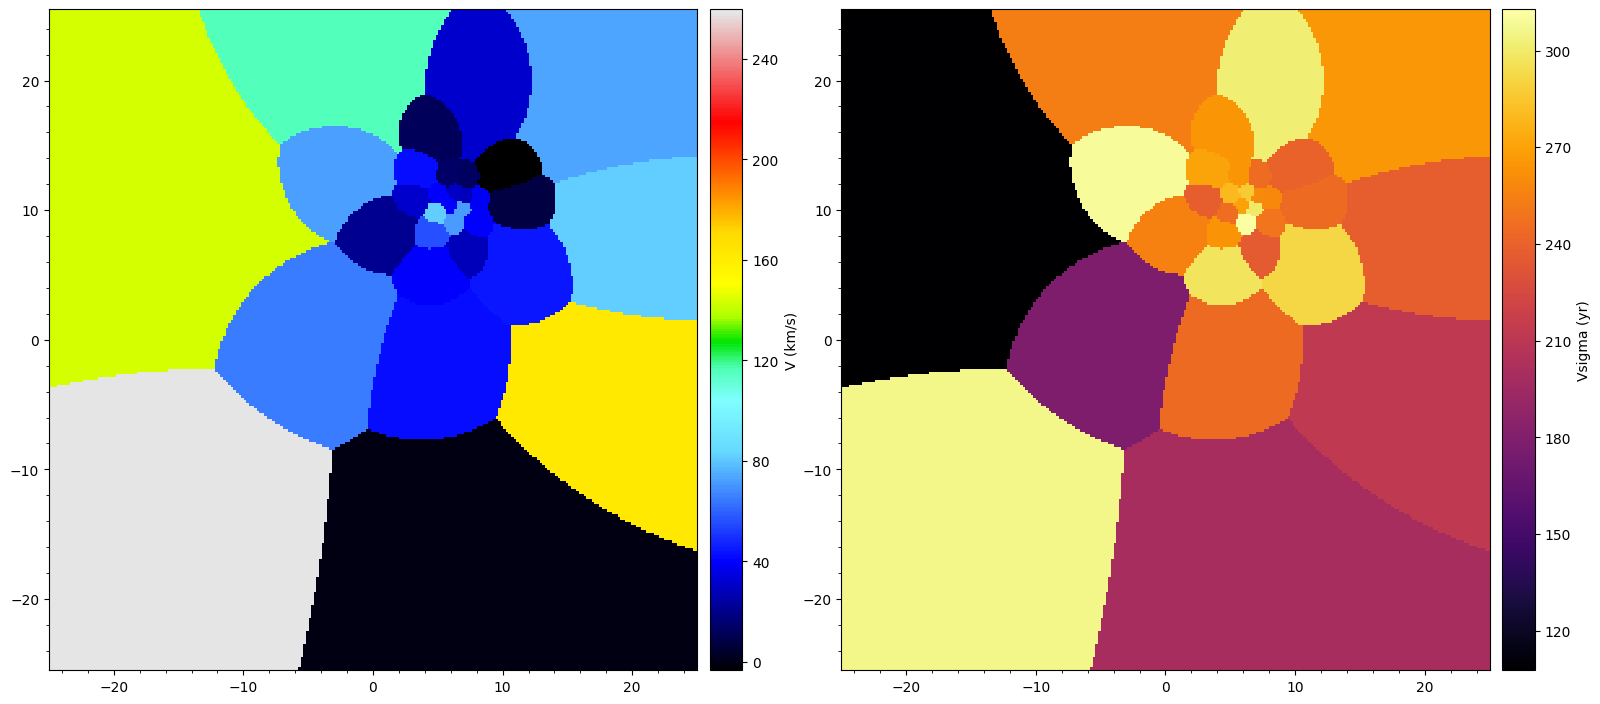

Saving stellar kinematic FITS maps...
94.46483612060547


In [4]:
t0 = time.time()
s.redshift = z

### 1. Voronoi binning and stellar kinematics
sk = ppxf_f.stellar_kinematics(
    s=s,
    target_sn=45,
    noise=s.noise,
    signal=s.signal,
    width_lines=1500,  # width to use to mask the emission lines
)

stars = sk.stellar_kinematics()
print(time.time()-t0)

In [ ]:
t0 = time.time()

fit_gas = ppxf_f.GasKinematicsFitter(
    s=s,
    sps=stars.sps,
    lam_gal=stars.lam_gal,
    velbin=stars.velbin,
    sigbin=stars.sigbin,
    h3=stars.h3,
    h4=stars.h4,
    bin_num=stars.bin_num,
    optimal_templates=stars.optimal_templates
)
resultado = ppxf_f.GasKinematicsFitter._fit_single_gaussian_static(4500, fit_gas.s.spectra, fit_gas.s.variance, fit_gas.sps.ln_lam_temp,
                fit_gas.lam_gal, fit_gas.bin_num, fit_gas.optimal_templates,
                fit_gas.gas_templates_1, fit_gas.gas_names_1,
                fit_gas.velbin, fit_gas.sigbin, fit_gas.h3, fit_gas.h4,
                fit_gas.s.velscale, fit_gas.sps.lam_temp)
print(resultado)
print(fit_gas)
print(time.time()-t0)

In [5]:
t0 = time.time()
fit_gas = ppxf_f.GasKinematicsFitter(
    s=s,
    sps=stars.sps,
    lam_gal=stars.lam_gal,
    velbin=stars.velbin,
    sigbin=stars.sigbin,
    h3=stars.h3,
    h4=stars.h4,
    bin_num=stars.bin_num,
    optimal_templates=stars.optimal_templates
)

fit_gas.Fit_cube_one_component(n_jobs=12)
fit_gas.Save_all_emission_lines_one_component()
print(time.time()-t0)

Emission lines included in gas templates:
['Hbeta' 'Halpha' '[SII]6716' '[SII]6731' '[NII]6548' '[NII]6584'
 '[OIII]4959' '[OIII]5007' 'HeII4687' 'HeI5876' '[NII]5755' '[NI]5198'
 '[NI]5200' '[OI]6300_d']


1-Gaussian gas fits: 100%|██████████| 63750/63750 [17:20<00:00, 61.24it/s]



Saving single-Gaussian maps for:
  → Halpha
  → Hbeta
  → HeI5876
  → HeII4687
  → [NII]5755
  → [NII]6548
  → [NII]6584
  → [NI]5198
  → [NI]5200
  → [OIII]4959
  → [OIII]5007
  → [OI]6300_d
  → [SII]6716
  → [SII]6731

✓ All emission-line maps saved.
1046.6676280498505


In [ ]:
#joblib.dump(fit_gas, 'fit_gas_obj.joblib', compress=3)

In [ ]:
#fit_gas = joblib.load('fit_gas_obj.joblib') #2'26"

In [ ]:
t0 = time.time()
# Run all spaxels two gaussians
fit_gas.Fit_cube(n_jobs=12)

# Build flux maps, component maps, weighted velocities
fit_gas.Process_all_lines()
print(time.time()-t0)